In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import AutoProcessor, Gemma3ForConditionalGeneration

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
MODEL_ID = "google/gemma-3-4b-it"

DATA_PATH = "/kaggle/input/datasets/amermahbub01/sentifive"

N_SAMPLES = 3000
SEED = 42

MAX_NEW_TOKENS = 64

print("Model:", MODEL_ID)
print("Dataset path:", DATA_PATH)
print("Evaluation samples:", N_SAMPLES)
print("Random seed:", SEED)
print("Max new tokens:", MAX_NEW_TOKENS)

Model: google/gemma-3-4b-it
Dataset path: /kaggle/input/datasets/amermahbub01/sentifive
Evaluation samples: 3000
Random seed: 42
Max new tokens: 64


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seeds set successfully.")

Random seeds set successfully.


In [5]:
csv_files = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
/kaggle/input/datasets/amermahbub01/sentifive/SentiFive.csv


In [7]:
DATA_FILE = csv_files[0]

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (31411, 2)

Columns:
['data', 'title']


,data,title
0,থিওরি অফ রিলেটিভিটির প্রেক্ষিতে বাংলা ভাষার এ...,নিশ্চিত ইতিবাচক
1,এডমিনকে অনুরোধ করব যারা এসব কাজ করে দুই বাংলার...,নিরপেক্ষ
2,খাদ্যগলিডেকার্স লেনে ভোজনচর্চা,নিরপেক্ষ
3,আদনান তোর বৌয়ের ভোদা খাবো খুব মিষ্টি রস বেরোয...,নিশ্চিত নেতিবাচক
4,কে কে আমার ভিডিও লাইক করলে,নিরপেক্ষ


In [8]:
print("Unique sentiment labels:")
print(df["title"].value_counts())

print("\nNumber of unique labels:", df["title"].nunique())

Unique sentiment labels:
title
নিশ্চিত নেতিবাচক    6780
নিশ্চিত ইতিবাচক     6537
নিরপেক্ষ            6453
কিছুটা নেতিবাচক     6006
কিছুটা ইতিবাচক      5635
Name: count, dtype: int64

Number of unique labels: 5


In [9]:
label_mapping = {
    "নিশ্চিত নেতিবাচক": 0,
    "কিছুটা নেতিবাচক": 1,
    "নিরপেক্ষ": 2,
    "কিছুটা ইতিবাচক": 3,
    "নিশ্চিত ইতিবাচক": 4
}

id_to_label = {
    0: "Strongly Negative",
    1: "Slightly Negative",
    2: "Neutral",
    3: "Slightly Positive",
    4: "Strongly Positive"
}

df["label_id"] = df["title"].map(label_mapping)

print("Missing label IDs:", df["label_id"].isna().sum())
print("\nLabel distribution:")
print(df["label_id"].value_counts().sort_index())

Missing label IDs: 0

Label distribution:
label_id
0    6780
1    6006
2    6453
3    5635
4    6537
Name: count, dtype: int64


In [10]:
assert df["label_id"].isna().sum() == 0, "Some labels were not mapped!"
assert df["data"].isna().sum() == 0, "Some comments are missing!"

print("Dataset verification successful.")
print("Total samples:", len(df))
print("Missing text:", df["data"].isna().sum())
print("Missing labels:", df["label_id"].isna().sum())

Dataset verification successful.
Total samples: 31411
Missing text: 0
Missing labels: 0


In [11]:
train_df, eval_df = train_test_split(
    df,
    test_size=N_SAMPLES,
    stratify=df["label_id"],
    random_state=SEED
)

train_df = train_df.copy()
eval_df = eval_df.copy()

print("Demonstration pool:", len(train_df))
print("Evaluation set:", len(eval_df))

print("\nEvaluation label distribution:")
print(eval_df["label_id"].value_counts().sort_index())

Demonstration pool: 28411
Evaluation set: 3000

Evaluation label distribution:
label_id
0    648
1    574
2    616
3    538
4    624
Name: count, dtype: int64


In [12]:
overlap = set(train_df.index).intersection(set(eval_df.index))

print("Overlapping samples:", len(overlap))

assert len(overlap) == 0, "Data leakage detected!"

print("No overlap between demonstration pool and evaluation set.")

Overlapping samples: 0
No overlap between demonstration pool and evaluation set.


In [14]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("tushartoken")

login(token=HF_TOKEN)

print("Hugging Face authentication successful.")

Hugging Face authentication successful.


In [15]:
from huggingface_hub import model_info

info = model_info(
    MODEL_ID,
    token=HF_TOKEN
)

print("Model access confirmed:", info.id)


Model access confirmed: google/gemma-3-4b-it


In [16]:
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    padding_side="left"
)

print("Gemma processor loaded successfully.")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Gemma processor loaded successfully.


In [17]:
model = Gemma3ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)

model.eval()

print("Gemma 3 4B model loaded successfully.")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Gemma 3 4B model loaded successfully.


In [18]:
LABEL_DEFINITIONS = """
You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.
"""


def build_zero_shot_prompt(comment):
    return f"""
{LABEL_DEFINITIONS}

Bengali comment:
{comment}

Label:
"""


def build_cot_prompt(comment):
    return f"""
{LABEL_DEFINITIONS}

Carefully analyze the sentiment of the Bengali comment before deciding.
Consider the overall meaning, emotional polarity, and intensity.

Do not provide your reasoning in the final response.

Bengali comment:
{comment}

Final label:
"""


print("Label definitions loaded.")
print("Zero-shot prompt function ready.")
print("CoT prompt function ready.")

Label definitions loaded.
Zero-shot prompt function ready.
CoT prompt function ready.


In [20]:
few_shot_examples = []

for label_id in range(5):
    candidates = train_df[train_df["label_id"] == label_id]
    
    example = candidates.iloc[0]
    
    few_shot_examples.append({
        "comment": example["data"],
        "label": label_id
    })

print("Few-shot examples created:")
print()

for example in few_shot_examples:
    print(f"Label {example['label']}:")
    print(example["comment"])
    print()

Few-shot examples created:

Label 0:
মাদারচুদ তরে আমি চুদব আমার মনের আশা মিতাব

Label 1:
ওনি আর কি বলবেওনি নাকি নিজেই ছাত্রলীগ করে আসছে

Label 2:
পাকিস্তান গেলে আর ইন্ডিয়ার ভিসা পাবো না 

Label 3:
চোখের জল আটকাতে পারলাম না লোকটা নিরপরাধ  আর এইটা আল্লাহর রহমত তা নাহলে এতটুকু মেয়ের দ্বারা এটা সম্ভব হতো না

Label 4:
ভাই আপনি এতো খান কিভাবে পেটে প্রব্লেম হই না



In [21]:
def build_few_shot_prompt(comment):
    examples_text = ""
    
    for example in few_shot_examples:
        examples_text += f"""
Bengali comment:
{example["comment"]}

Label:
{example["label"]}

"""
    
    return f"""
{LABEL_DEFINITIONS}

Here are examples of previously classified Bengali comments:

{examples_text}

Now classify the following Bengali comment.

Bengali comment:
{comment}

Label:
"""


print("Few-shot prompt function ready.")

Few-shot prompt function ready.


In [22]:
def extract_label(response):
    """
    Extract a valid sentiment label (0-4) from the model response.
    Returns -1 if no valid label is found.
    """
    
    response = str(response).strip()
    
    # First, look for an isolated digit from 0 to 4.
    matches = re.findall(r"(?<!\d)[0-4](?!\d)", response)
    
    if matches:
        return int(matches[-1])
    
    return -1


# Test the extraction function
test_responses = [
    "0",
    "Label: 3",
    "The answer is 4.",
    "2\n",
    "Sentiment = 1"
]

print("Extraction tests:")

for response in test_responses:
    print(f"{response!r} -> {extract_label(response)}")

Extraction tests:
'0' -> 0
'Label: 3' -> 3
'The answer is 4.' -> 4
'2\n' -> 2
'Sentiment = 1' -> 1


In [23]:
def generate_prediction(prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )

    # Move inputs to the same device as the model
    inputs = {
        key: value.to(model.device) if torch.is_tensor(value) else value
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # Only decode newly generated tokens
    input_length = inputs["input_ids"].shape[-1]
    generated_tokens = outputs[:, input_length:]

    response = processor.decode(
        generated_tokens[0],
        skip_special_tokens=True
    ).strip()

    predicted_label = extract_label(response)

    return predicted_label, response


print("Gemma prediction function ready.")

Gemma prediction function ready.


In [24]:
test_comment = eval_df.iloc[0]["data"]
true_label = int(eval_df.iloc[0]["label_id"])

test_prompt = build_zero_shot_prompt(test_comment)

predicted_label, raw_response = generate_prediction(test_prompt)

print("Bengali comment:")
print(test_comment)

print("\nTrue label:")
print(f"{true_label} = {id_to_label[true_label]}")

print("\nModel raw response:")
print(repr(raw_response))

print("\nPredicted label:")
if predicted_label in id_to_label:
    print(f"{predicted_label} = {id_to_label[predicted_label]}")
else:
    print("Invalid prediction:", predicted_label)

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Bengali comment:
বেডা খায় কেমনে ছুছা বেডা

True label:
3 = Slightly Positive

Model raw response:
'0'

Predicted label:
0 = Strongly Negative


In [25]:
# Use the exact same evaluation comment for all strategies
test_comment = eval_df.iloc[0]["data"]
true_label = int(eval_df.iloc[0]["label_id"])

prompts = {
    "Zero-shot": build_zero_shot_prompt(test_comment),
    "CoT": build_cot_prompt(test_comment),
    "Few-shot": build_few_shot_prompt(test_comment)
}

print("Test comment:")
print(test_comment)

print("\nTrue label:")
print(f"{true_label} = {id_to_label[true_label]}")

print("\n" + "=" * 60)

for strategy, prompt in prompts.items():
    predicted_label, raw_response = generate_prediction(prompt)

    print(f"\n{strategy}")
    print("-" * 30)
    print("Raw response:", repr(raw_response))
    print("Predicted label:", predicted_label)

    if predicted_label in id_to_label:
        print("Predicted sentiment:", id_to_label[predicted_label])

Test comment:
বেডা খায় কেমনে ছুছা বেডা

True label:
3 = Slightly Positive


Zero-shot
------------------------------
Raw response: '0'
Predicted label: 0
Predicted sentiment: Strongly Negative

CoT
------------------------------
Raw response: '0'
Predicted label: 0
Predicted sentiment: Strongly Negative

Few-shot
------------------------------
Raw response: '1'
Predicted label: 1
Predicted sentiment: Slightly Negative


In [26]:
eval_comments = eval_df["data"].tolist()
eval_labels = eval_df["label_id"].astype(int).tolist()

print("Evaluation comments:", len(eval_comments))
print("Evaluation labels:", len(eval_labels))

assert len(eval_comments) == N_SAMPLES
assert len(eval_labels) == N_SAMPLES

print("Evaluation set is ready for inference.")

Evaluation comments: 3000
Evaluation labels: 3000
Evaluation set is ready for inference.


In [27]:
zero_shot_predictions = []
zero_shot_raw_responses = []

for i, comment in enumerate(eval_comments):

    prompt = build_zero_shot_prompt(comment)

    predicted_label, raw_response = generate_prediction(prompt)

    zero_shot_predictions.append(predicted_label)
    zero_shot_raw_responses.append(raw_response)

    if (i + 1) % 100 == 0 or i == 0:
        valid = sum(p in range(5) for p in zero_shot_predictions)
        print(
            f"Processed {i + 1}/{len(eval_comments)} "
            f"| Valid predictions: {valid}/{i + 1}"
        )

print("\nZero-shot inference completed.")
print("Total predictions:", len(zero_shot_predictions))
print(
    "Invalid predictions:",
    sum(p not in range(5) for p in zero_shot_predictions)
)

Processed 1/3000 | Valid predictions: 1/1
Processed 100/3000 | Valid predictions: 100/100
Processed 200/3000 | Valid predictions: 200/200
Processed 300/3000 | Valid predictions: 300/300
Processed 400/3000 | Valid predictions: 400/400
Processed 500/3000 | Valid predictions: 500/500
Processed 600/3000 | Valid predictions: 600/600
Processed 700/3000 | Valid predictions: 700/700
Processed 800/3000 | Valid predictions: 800/800
Processed 900/3000 | Valid predictions: 900/900
Processed 1000/3000 | Valid predictions: 1000/1000
Processed 1100/3000 | Valid predictions: 1100/1100
Processed 1200/3000 | Valid predictions: 1200/1200
Processed 1300/3000 | Valid predictions: 1300/1300
Processed 1400/3000 | Valid predictions: 1400/1400
Processed 1500/3000 | Valid predictions: 1500/1500
Processed 1600/3000 | Valid predictions: 1600/1600
Processed 1700/3000 | Valid predictions: 1700/1700
Processed 1800/3000 | Valid predictions: 1800/1800
Processed 1900/3000 | Valid predictions: 1900/1900
Processed 2000/3

In [28]:
zero_shot_accuracy = accuracy_score(
    eval_labels,
    zero_shot_predictions
)

zero_shot_precision, zero_shot_recall, zero_shot_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        zero_shot_predictions,
        average="weighted",
        zero_division=0
    )
)

print("ZERO-SHOT RESULTS")
print("=" * 50)

print(f"Accuracy:  {zero_shot_accuracy:.4f}")
print(f"Precision: {zero_shot_precision:.4f}")
print(f"Recall:    {zero_shot_recall:.4f}")
print(f"F1-score:  {zero_shot_f1:.4f}")

ZERO-SHOT RESULTS
Accuracy:  0.3763
Precision: 0.3904
Recall:    0.3763
F1-score:  0.3577


In [29]:
zero_shot_report = classification_report(
    eval_labels,
    zero_shot_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    digits=4,
    zero_division=0
)

print("ZERO-SHOT CLASS-WISE RESULTS")
print("=" * 70)
print(zero_shot_report)

ZERO-SHOT CLASS-WISE RESULTS
                   precision    recall  f1-score   support

Strongly Negative     0.4368    0.6080    0.5084       648
Slightly Negative     0.2750    0.3641    0.3133       574
          Neutral     0.3564    0.4935    0.4139       616
Slightly Positive     0.2626    0.0967    0.1413       538
Strongly Positive     0.5923    0.2724    0.3732       624

         accuracy                         0.3763      3000
        macro avg     0.3846    0.3669    0.3500      3000
     weighted avg     0.3904    0.3763    0.3577      3000



In [30]:
zero_shot_cm = confusion_matrix(
    eval_labels,
    zero_shot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("ZERO-SHOT CONFUSION MATRIX")
print("=" * 50)

print("Rows = True labels")
print("Columns = Predicted labels")
print()

print(pd.DataFrame(
    zero_shot_cm,
    index=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    columns=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ]
))

ZERO-SHOT CONFUSION MATRIX
Rows = True labels
Columns = Predicted labels

                   Strongly Negative  Slightly Negative  Neutral  \
Strongly Negative                394                176       61   
Slightly Negative                208                209      124   
Neutral                          101                146      304   
Slightly Positive                110                150      170   
Strongly Positive                 89                 79      194   

                   Slightly Positive  Strongly Positive  
Strongly Negative                  8                  9  
Slightly Negative                 13                 20  
Neutral                           33                 32  
Slightly Positive                 52                 56  
Strongly Positive                 92                170  


In [31]:
cot_predictions = []
cot_raw_responses = []

for i, comment in enumerate(eval_comments):

    prompt = build_cot_prompt(comment)

    predicted_label, raw_response = generate_prediction(prompt)

    cot_predictions.append(predicted_label)
    cot_raw_responses.append(raw_response)

    if (i + 1) % 100 == 0 or i == 0:
        valid = sum(p in range(5) for p in cot_predictions)
        print(
            f"Processed {i + 1}/{len(eval_comments)} "
            f"| Valid predictions: {valid}/{i + 1}"
        )

print("\nCoT inference completed.")
print("Total predictions:", len(cot_predictions))
print(
    "Invalid predictions:",
    sum(p not in range(5) for p in cot_predictions)
)

Processed 1/3000 | Valid predictions: 1/1
Processed 100/3000 | Valid predictions: 100/100
Processed 200/3000 | Valid predictions: 200/200
Processed 300/3000 | Valid predictions: 300/300
Processed 400/3000 | Valid predictions: 400/400
Processed 500/3000 | Valid predictions: 500/500
Processed 600/3000 | Valid predictions: 600/600
Processed 700/3000 | Valid predictions: 700/700
Processed 800/3000 | Valid predictions: 800/800
Processed 900/3000 | Valid predictions: 900/900
Processed 1000/3000 | Valid predictions: 1000/1000
Processed 1100/3000 | Valid predictions: 1100/1100
Processed 1200/3000 | Valid predictions: 1200/1200
Processed 1300/3000 | Valid predictions: 1300/1300
Processed 1400/3000 | Valid predictions: 1400/1400
Processed 1500/3000 | Valid predictions: 1500/1500
Processed 1600/3000 | Valid predictions: 1600/1600
Processed 1700/3000 | Valid predictions: 1700/1700
Processed 1800/3000 | Valid predictions: 1800/1800
Processed 1900/3000 | Valid predictions: 1900/1900
Processed 2000/3

In [32]:
cot_accuracy = accuracy_score(
    eval_labels,
    cot_predictions
)

cot_precision, cot_recall, cot_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        cot_predictions,
        average="weighted",
        zero_division=0
    )
)

print("COT RESULTS")
print("=" * 50)

print(f"Accuracy:  {cot_accuracy:.4f}")
print(f"Precision: {cot_precision:.4f}")
print(f"Recall:    {cot_recall:.4f}")
print(f"F1-score:  {cot_f1:.4f}")

COT RESULTS
Accuracy:  0.3703
Precision: 0.3857
Recall:    0.3703
F1-score:  0.3555


In [33]:
cot_report = classification_report(
    eval_labels,
    cot_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    digits=4,
    zero_division=0
)

print("COT CLASS-WISE RESULTS")
print("=" * 70)
print(cot_report)

COT CLASS-WISE RESULTS
                   precision    recall  f1-score   support

Strongly Negative     0.4580    0.5556    0.5021       648
Slightly Negative     0.2777    0.4059    0.3298       574
          Neutral     0.3505    0.4870    0.4076       616
Slightly Positive     0.2415    0.1059    0.1473       538
Strongly Positive     0.5689    0.2580    0.3550       624

         accuracy                         0.3703      3000
        macro avg     0.3793    0.3625    0.3484      3000
     weighted avg     0.3857    0.3703    0.3555      3000



In [34]:
cot_cm = confusion_matrix(
    eval_labels,
    cot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("COT CONFUSION MATRIX")
print("=" * 50)

print("Rows = True labels")
print("Columns = Predicted labels")
print()

print(pd.DataFrame(
    cot_cm,
    index=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    columns=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ]
))

COT CONFUSION MATRIX
Rows = True labels
Columns = Predicted labels

                   Strongly Negative  Slightly Negative  Neutral  \
Strongly Negative                360                208       57   
Slightly Negative                181                233      122   
Neutral                           85                161      300   
Slightly Positive                 91                153      179   
Strongly Positive                 69                 84      198   

                   Slightly Positive  Strongly Positive  
Strongly Negative                  9                 14  
Slightly Negative                 16                 22  
Neutral                           42                 28  
Slightly Positive                 57                 58  
Strongly Positive                112                161  


In [35]:
few_shot_predictions = []
few_shot_raw_responses = []

for i, comment in enumerate(eval_comments):

    prompt = build_few_shot_prompt(comment)

    predicted_label, raw_response = generate_prediction(prompt)

    few_shot_predictions.append(predicted_label)
    few_shot_raw_responses.append(raw_response)

    if (i + 1) % 100 == 0 or i == 0:
        valid = sum(p in range(5) for p in few_shot_predictions)
        print(
            f"Processed {i + 1}/{len(eval_comments)} "
            f"| Valid predictions: {valid}/{i + 1}"
        )

print("\nFew-shot inference completed.")
print("Total predictions:", len(few_shot_predictions))
print(
    "Invalid predictions:",
    sum(p not in range(5) for p in few_shot_predictions)
)

Processed 1/3000 | Valid predictions: 1/1
Processed 100/3000 | Valid predictions: 100/100
Processed 200/3000 | Valid predictions: 200/200
Processed 300/3000 | Valid predictions: 300/300
Processed 400/3000 | Valid predictions: 400/400
Processed 500/3000 | Valid predictions: 500/500
Processed 600/3000 | Valid predictions: 600/600
Processed 700/3000 | Valid predictions: 700/700
Processed 800/3000 | Valid predictions: 800/800
Processed 900/3000 | Valid predictions: 900/900
Processed 1000/3000 | Valid predictions: 1000/1000
Processed 1100/3000 | Valid predictions: 1100/1100
Processed 1200/3000 | Valid predictions: 1200/1200
Processed 1300/3000 | Valid predictions: 1300/1300
Processed 1400/3000 | Valid predictions: 1400/1400
Processed 1500/3000 | Valid predictions: 1500/1500
Processed 1600/3000 | Valid predictions: 1600/1600
Processed 1700/3000 | Valid predictions: 1700/1700
Processed 1800/3000 | Valid predictions: 1800/1800
Processed 1900/3000 | Valid predictions: 1900/1900
Processed 2000/3

In [36]:
few_shot_accuracy = accuracy_score(
    eval_labels,
    few_shot_predictions
)

few_shot_precision, few_shot_recall, few_shot_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        few_shot_predictions,
        average="weighted",
        zero_division=0
    )
)

print("FEW-SHOT RESULTS")
print("=" * 50)

print(f"Accuracy:  {few_shot_accuracy:.4f}")
print(f"Precision: {few_shot_precision:.4f}")
print(f"Recall:    {few_shot_recall:.4f}")
print(f"F1-score:  {few_shot_f1:.4f}")

FEW-SHOT RESULTS
Accuracy:  0.3810
Precision: 0.4069
Recall:    0.3810
F1-score:  0.3762


In [37]:
few_shot_report = classification_report(
    eval_labels,
    few_shot_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    digits=4,
    zero_division=0
)

print("FEW-SHOT CLASS-WISE RESULTS")
print("=" * 70)
print(few_shot_report)

FEW-SHOT CLASS-WISE RESULTS
                   precision    recall  f1-score   support

Strongly Negative     0.5060    0.3935    0.4427       648
Slightly Negative     0.2866    0.5697    0.3813       574
          Neutral     0.4049    0.4286    0.4164       616
Slightly Positive     0.2525    0.1413    0.1812       538
Strongly Positive     0.5498    0.3542    0.4308       624

         accuracy                         0.3810      3000
        macro avg     0.3999    0.3774    0.3705      3000
     weighted avg     0.4069    0.3810    0.3762      3000



In [38]:
few_shot_cm = confusion_matrix(
    eval_labels,
    few_shot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("FEW-SHOT CONFUSION MATRIX")
print("=" * 50)

print("Rows = True labels")
print("Columns = Predicted labels")
print()

print(pd.DataFrame(
    few_shot_cm,
    index=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ],
    columns=[
        "Strongly Negative",
        "Slightly Negative",
        "Neutral",
        "Slightly Positive",
        "Strongly Positive"
    ]
))

FEW-SHOT CONFUSION MATRIX
Rows = True labels
Columns = Predicted labels

                   Strongly Negative  Slightly Negative  Neutral  \
Strongly Negative                255                316       47   
Slightly Negative                105                327       80   
Neutral                           45                211      264   
Slightly Positive                 57                186      132   
Strongly Positive                 42                101      129   

                   Slightly Positive  Strongly Positive  
Strongly Negative                 16                 14  
Slightly Negative                 33                 29  
Neutral                           45                 51  
Slightly Positive                 76                 87  
Strongly Positive                131                221  


In [39]:
comparison_df = pd.DataFrame({
    "Strategy": [
        "Zero-shot",
        "CoT",
        "Few-shot"
    ],
    "Accuracy": [
        zero_shot_accuracy,
        cot_accuracy,
        few_shot_accuracy
    ],
    "Weighted Precision": [
        zero_shot_precision,
        cot_precision,
        few_shot_precision
    ],
    "Weighted Recall": [
        zero_shot_recall,
        cot_recall,
        few_shot_recall
    ],
    "Weighted F1": [
        zero_shot_f1,
        cot_f1,
        few_shot_f1
    ]
})

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

print("Final strategy comparison generated.")

,Strategy,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Zero-shot,0.3763,0.3904,0.3763,0.3577
1,CoT,0.3703,0.3857,0.3703,0.3555
2,Few-shot,0.3810,0.4069,0.3810,0.3762


Final strategy comparison generated.


In [41]:
class_names = [
    "Strongly Negative",
    "Slightly Negative",
    "Neutral",
    "Slightly Positive",
    "Strongly Positive"
]

cm_comparison = pd.DataFrame(
    {
        "Zero-shot": zero_shot_cm.flatten(),
        "CoT": cot_cm.flatten(),
        "Few-shot": few_shot_cm.flatten()
    },
    index=[
        f"True {class_names[i]} → Pred {class_names[j]}"
        for i in range(5)
        for j in range(5)
    ]
)

display(cm_comparison)

print("Confusion matrix comparison generated.")

,Zero-shot,CoT,Few-shot
True Strongly Negative → Pred Strongly Negative,394,360,255
True Strongly Negative → Pred Slightly Negative,176,208,316
True Strongly Negative → Pred Neutral,61,57,47
True Strongly Negative → Pred Slightly Positive,8,9,16
True Strongly Negative → Pred Strongly Positive,9,14,14
True Slightly Negative → Pred Strongly Negative,208,181,105
True Slightly Negative → Pred Slightly Negative,209,233,327
True Slightly Negative → Pred Neutral,124,122,80
True Slightly Negative → Pred Slightly Positive,13,16,33
True Slightly Negative → Pred Strongly Positive,20,22,29


Confusion matrix comparison generated.


In [42]:
distribution_df = pd.DataFrame({
    "True": pd.Series(eval_labels).value_counts().sort_index(),
    "Zero-shot": pd.Series(zero_shot_predictions).value_counts().sort_index(),
    "CoT": pd.Series(cot_predictions).value_counts().sort_index(),
    "Few-shot": pd.Series(few_shot_predictions).value_counts().sort_index()
})

distribution_df.index = [
    "Strongly Negative",
    "Slightly Negative",
    "Neutral",
    "Slightly Positive",
    "Strongly Positive"
]

print("TRUE VS PREDICTED LABEL DISTRIBUTION")
print("=" * 70)

display(distribution_df)

print("\nPercentages:")
display(
    (distribution_df / len(eval_labels) * 100).round(2)
)

TRUE VS PREDICTED LABEL DISTRIBUTION


,True,Zero-shot,CoT,Few-shot
Strongly Negative,648,902,786,504
Slightly Negative,574,760,839,1141
Neutral,616,853,856,652
Slightly Positive,538,198,236,301
Strongly Positive,624,287,283,402



Percentages:


,True,Zero-shot,CoT,Few-shot
Strongly Negative,21.60,30.07,26.20,16.80
Slightly Negative,19.13,25.33,27.97,38.03
Neutral,20.53,28.43,28.53,21.73
Slightly Positive,17.93,6.60,7.87,10.03
Strongly Positive,20.80,9.57,9.43,13.40


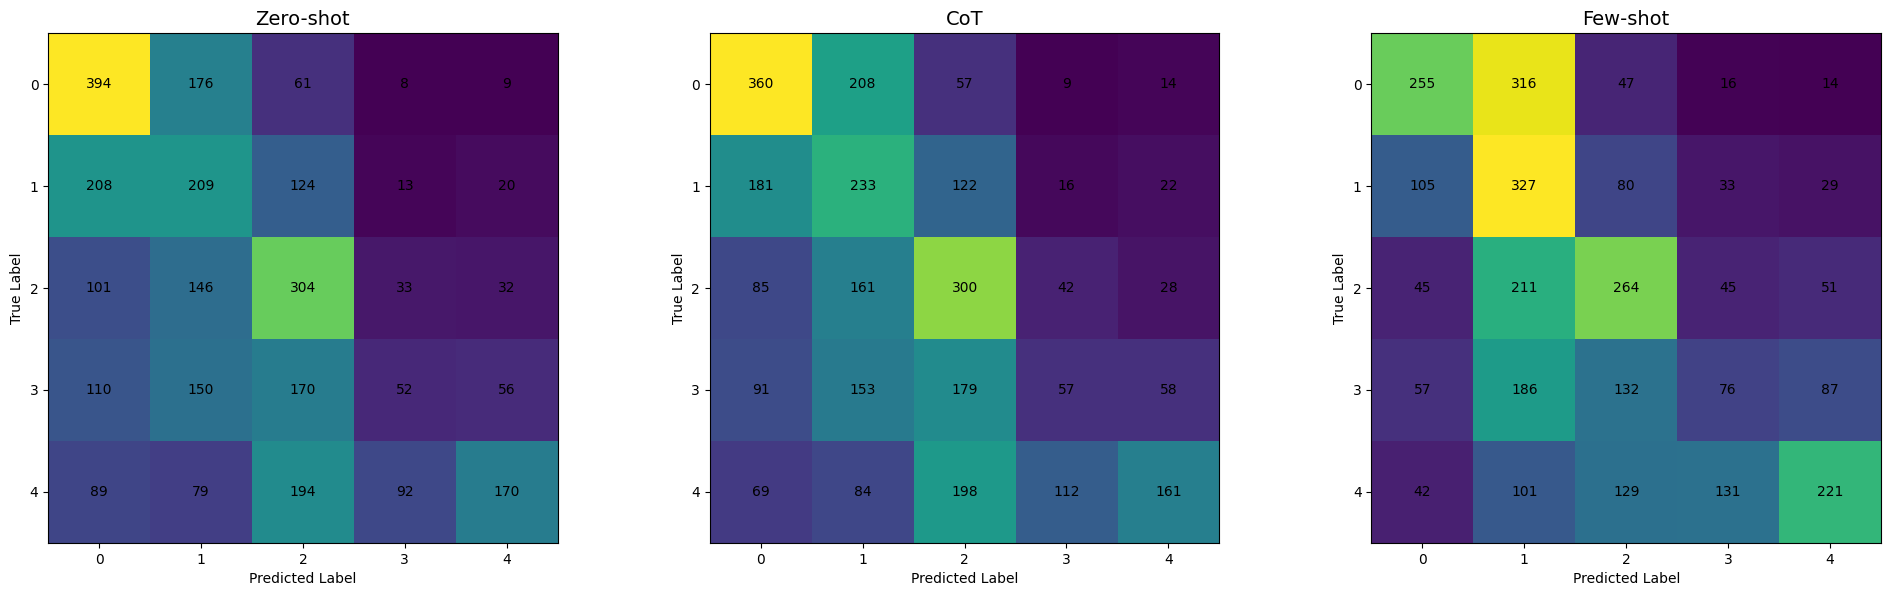

In [43]:
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "Strongly Negative",
    "Slightly Negative",
    "Neutral",
    "Slightly Positive",
    "Strongly Positive"
]

confusion_matrices = {
    "Zero-shot": zero_shot_cm,
    "CoT": cot_cm,
    "Few-shot": few_shot_cm
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (strategy, cm) in zip(axes, confusion_matrices.items()):
    im = ax.imshow(cm)

    ax.set_title(strategy, fontsize=14)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks(range(5))
    ax.set_yticks(range(5))

    ax.set_xticklabels(range(5))
    ax.set_yticklabels(range(5))

    for i in range(5):
        for j in range(5):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

In [44]:
def get_top_confusions(cm, class_names, top_n=10):
    confusions = []

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                confusions.append({
                    "True Class": class_names[i],
                    "Predicted Class": class_names[j],
                    "Count": cm[i, j]
                })

    return (
        pd.DataFrame(confusions)
        .sort_values("Count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


print("TOP 10 MISCLASSIFICATIONS — ZERO-SHOT")
print("=" * 60)
display(get_top_confusions(zero_shot_cm, class_names))

print("\nTOP 10 MISCLASSIFICATIONS — CoT")
print("=" * 60)
display(get_top_confusions(cot_cm, class_names))

print("\nTOP 10 MISCLASSIFICATIONS — FEW-SHOT")
print("=" * 60)
display(get_top_confusions(few_shot_cm, class_names))

TOP 10 MISCLASSIFICATIONS — ZERO-SHOT


,True Class,Predicted Class,Count
0,Slightly Negative,Strongly Negative,208
1,Strongly Positive,Neutral,194
2,Strongly Negative,Slightly Negative,176
3,Slightly Positive,Neutral,170
4,Slightly Positive,Slightly Negative,150
5,Neutral,Slightly Negative,146
6,Slightly Negative,Neutral,124
7,Slightly Positive,Strongly Negative,110
8,Neutral,Strongly Negative,101
9,Strongly Positive,Slightly Positive,92



TOP 10 MISCLASSIFICATIONS — CoT


,True Class,Predicted Class,Count
0,Strongly Negative,Slightly Negative,208
1,Strongly Positive,Neutral,198
2,Slightly Negative,Strongly Negative,181
3,Slightly Positive,Neutral,179
4,Neutral,Slightly Negative,161
5,Slightly Positive,Slightly Negative,153
6,Slightly Negative,Neutral,122
7,Strongly Positive,Slightly Positive,112
8,Slightly Positive,Strongly Negative,91
9,Neutral,Strongly Negative,85



TOP 10 MISCLASSIFICATIONS — FEW-SHOT


,True Class,Predicted Class,Count
0,Strongly Negative,Slightly Negative,316
1,Neutral,Slightly Negative,211
2,Slightly Positive,Slightly Negative,186
3,Slightly Positive,Neutral,132
4,Strongly Positive,Slightly Positive,131
5,Strongly Positive,Neutral,129
6,Slightly Negative,Strongly Negative,105
7,Strongly Positive,Slightly Negative,101
8,Slightly Positive,Strongly Positive,87
9,Slightly Negative,Neutral,80
